In [2]:
import pyodbc
import pandas as pd

conn = pyodbc.connect(
    'DRIVER={SQL Server};'
    'SERVER=JAFFERMIYA;'
    'DATABASE=Chinook;'
    'Trusted_Connection=yes;'
)

print("Connected Successfully!")


Connected Successfully!


In [3]:
# Load main tables
df_album = pd.read_sql("SELECT * FROM Album", conn)
df_artist = pd.read_sql("SELECT * FROM Artist", conn)
df_customer = pd.read_sql("SELECT * FROM Customer", conn)
df_employee = pd.read_sql("SELECT * FROM Employee", conn)
df_genre = pd.read_sql("SELECT * FROM Genre", conn)
df_invoice = pd.read_sql("SELECT * FROM Invoice", conn)
df_invoiceline = pd.read_sql("SELECT * FROM InvoiceLine", conn)
df_mediatype = pd.read_sql("SELECT * FROM MediaType", conn)
df_playlist = pd.read_sql("SELECT * FROM Playlist", conn)
df_playlisttrack = pd.read_sql("SELECT * FROM PlaylistTrack", conn)
df_track = pd.read_sql("SELECT * FROM Track", conn)

print("All 11 tables loaded successfully!")

C:\Users\jaffe\AppData\Local\Temp\ipykernel_9380\1052864061.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_album = pd.read_sql("SELECT * FROM Album", conn)
C:\Users\jaffe\AppData\Local\Temp\ipykernel_9380\1052864061.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_artist = pd.read_sql("SELECT * FROM Artist", conn)
C:\Users\jaffe\AppData\Local\Temp\ipykernel_9380\1052864061.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_customer = pd.read_sql("SELECT * FROM Customer", conn)
C:\Users\jaffe\AppData\Local\

All 11 tables loaded successfully!


C:\Users\jaffe\AppData\Local\Temp\ipykernel_9380\1407264072.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales, y=artists, palette='rocket')


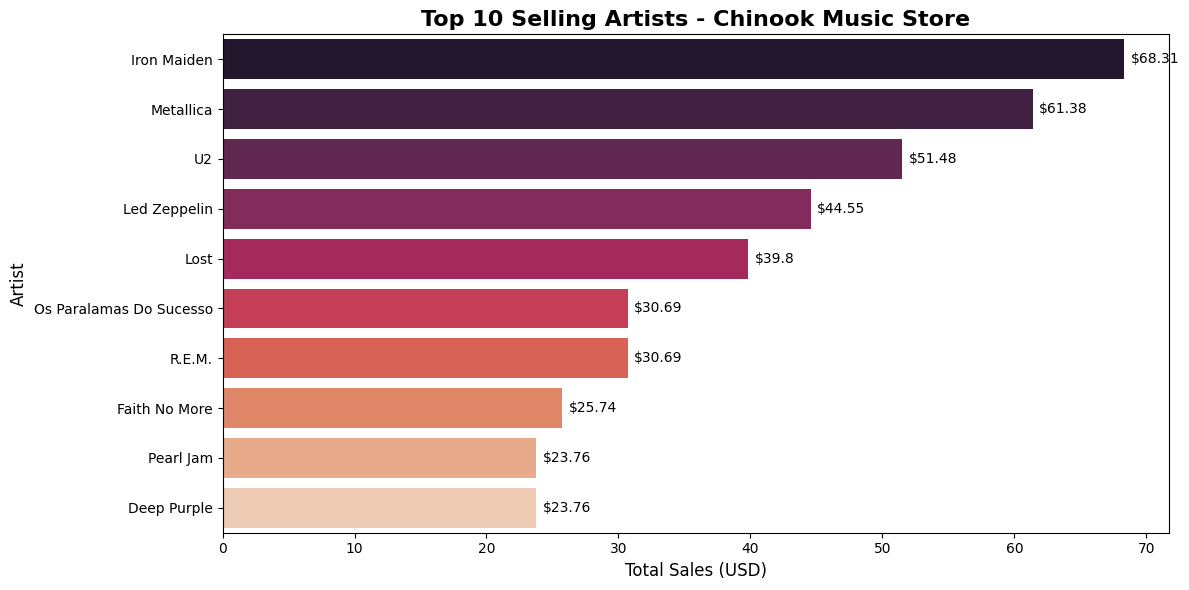

Chart saved!


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data from your SQL query
artists = ['Iron Maiden', 'Metallica', 'U2', 'Led Zeppelin', 'Lost', 
           'Os Paralamas Do Sucesso', 'R.E.M.', 'Faith No More', 'Pearl Jam', 'Deep Purple']

sales = [68.31, 61.38, 51.48, 44.55, 39.80, 30.69, 30.69, 25.74, 23.76, 23.76]

# Create figure
plt.figure(figsize=(12, 6))
sns.barplot(x=sales, y=artists, palette='rocket')

# Labels
plt.title('Top 10 Selling Artists - Chinook Music Store', fontsize=16, fontweight='bold')
plt.xlabel('Total Sales (USD)', fontsize=12)
plt.ylabel('Artist', fontsize=12)

# Add value labels on bars
for i, v in enumerate(sales):
    plt.text(v + 0.5, i, f'${v}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('top_artists.png', dpi=150)
plt.show()

print("Chart saved!")

In [5]:
# Pull directly from DB
df_artists = pd.read_sql("""
    SELECT TOP 10 ar.Name AS Artist,
           SUM(il.UnitPrice * il.Quantity) AS TotalSales
    FROM InvoiceLine il
    JOIN Track t ON il.TrackId = t.TrackId
    JOIN Album al ON t.AlbumId = al.AlbumId
    JOIN Artist ar ON al.ArtistId = ar.ArtistId
    GROUP BY ar.ArtistId, ar.Name
    ORDER BY TotalSales DESC
""", conn)

print(df_artists)

                    Artist  TotalSales
0              Iron Maiden       68.31
1                Metallica       61.38
2                       U2       51.48
3             Led Zeppelin       44.55
4                     Lost       39.80
5  Os Paralamas Do Sucesso       30.69
6                   R.E.M.       30.69
7            Faith No More       25.74
8                Pearl Jam       23.76
9              Deep Purple       23.76


C:\Users\jaffe\AppData\Local\Temp\ipykernel_9380\998310521.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_artists = pd.read_sql("""


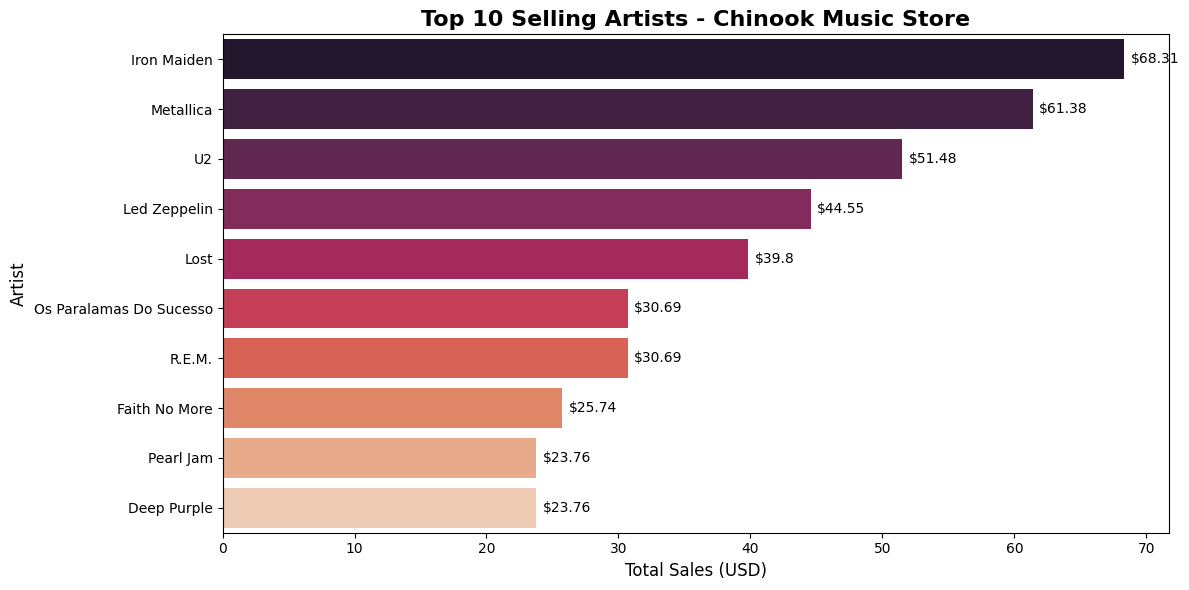

Chart 1 Done!


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x='TotalSales', y='Artist', data=df_artists, hue='Artist', palette='rocket', legend=False)
# Title and labels
plt.title('Top 10 Selling Artists - Chinook Music Store', fontsize=16, fontweight='bold')
plt.xlabel('Total Sales (USD)', fontsize=12)
plt.ylabel('Artist', fontsize=12)

# Add value labels on bars
for i, v in enumerate(df_artists['TotalSales']):
    plt.text(v + 0.5, i, f'${v}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('top_artists.png', dpi=150)
plt.show()

print("Chart 1 Done!")

### 💡 Insight:
Iron Maiden leads all artists with $68.31 in total sales, 
followed by Metallica at $61.38.

In [8]:
df_genre = pd.read_sql("""
     SELECT TOP 5 
       g.GenreId,
       g.Name AS Genre,
       SUM(il.Quantity) AS TracksSold
FROM Genre g
JOIN Track t
     ON g.GenreId = t.GenreId
JOIN InvoiceLine il
     ON t.TrackId = il.TrackId
GROUP BY g.GenreId, g.Name
ORDER BY TracksSold DESC
""", conn)

print(df_genre)

   GenreId               Genre  TracksSold
0        1                Rock         487
1        7               Latin         207
2        4  Alternative & Punk         158
3        3               Metal         146
4        2                Jazz          44


C:\Users\jaffe\AppData\Local\Temp\ipykernel_9380\945495360.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_genre = pd.read_sql("""


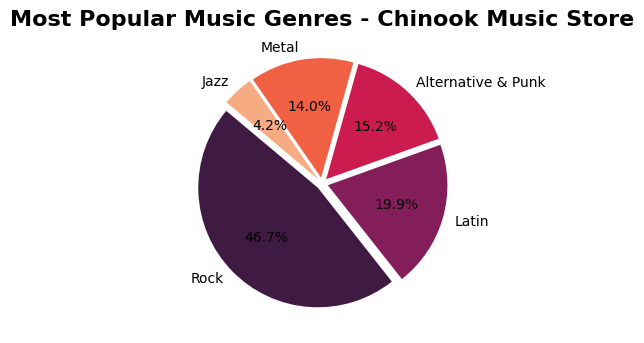

Chart 2 Done! ✅


In [11]:
plt.figure(figsize=(4, 4))
plt.pie(df_genre['TracksSold'], 
        labels=df_genre['Genre'],
        autopct='%1.1f%%',
        colors=sns.color_palette('rocket', len(df_genre)),
        startangle=140,
        explode=[0.05, 0.05, 0.05, 0.05, 0.05])

plt.title('Most Popular Music Genres - Chinook Music Store', 
          fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('chart2_genre_popularity.png', dpi=150)
plt.show()

print("Chart 2 Done! ✅")

### 💡 Insight:
Rock dominates genre popularity with 47.1% of total tracks sold,
nearly double Latin which comes second at 20%.